<a href="https://colab.research.google.com/github/Radheychoudhary1/Web-Ui-Testing-App-Backend/blob/main/ui_bug_detection_cnn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!ls /content/drive/MyDrive

 cnn-dataset.zip  'Colab Notebooks'


In [6]:
!cp /content/drive/MyDrive/cnn-dataset.zip /content/

In [8]:
!unzip cnn-dataset.zip

Archive:  cnn-dataset.zip
   creating: CNN Dataset/
   creating: CNN Dataset/Correct_UI/
  inflating: CNN Dataset/Correct_UI/0.jpg  
  inflating: CNN Dataset/Correct_UI/10.jpg  
  inflating: CNN Dataset/Correct_UI/11.jpg  
  inflating: CNN Dataset/Correct_UI/17.jpg  
  inflating: CNN Dataset/Correct_UI/18.jpg  
  inflating: CNN Dataset/Correct_UI/19.jpg  
  inflating: CNN Dataset/Correct_UI/2.jpg  
  inflating: CNN Dataset/Correct_UI/21.jpg  
  inflating: CNN Dataset/Correct_UI/22.jpg  
  inflating: CNN Dataset/Correct_UI/23.jpg  
  inflating: CNN Dataset/Correct_UI/25.jpg  
  inflating: CNN Dataset/Correct_UI/27.jpg  
  inflating: CNN Dataset/Correct_UI/28.jpg  
  inflating: CNN Dataset/Correct_UI/29.jpg  
  inflating: CNN Dataset/Correct_UI/30.jpg  
  inflating: CNN Dataset/Correct_UI/31.jpg  
  inflating: CNN Dataset/Correct_UI/34.jpg  
  inflating: CNN Dataset/Correct_UI/36.jpg  
  inflating: CNN Dataset/Correct_UI/40.jpg  
  inflating: CNN Dataset/Correct_UI/41.jpg  
  inflating: 

In [9]:
!ls cnn-dataset

ls: cannot access 'cnn-dataset': No such file or directory


In [10]:
!pip install tensorflow opencv-python matplotlib scikit-learn

In [18]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

dataset_path = "CNN Dataset"

img_size = (224,224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Found 64 images belonging to 5 classes.
Found 14 images belonging to 5 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.2812 - loss: 1.7721 - val_accuracy: 0.7143 - val_loss: 0.9470
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - accuracy: 0.6562 - loss: 1.1111 - val_accuracy: 0.7143 - val_loss: 0.8540
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.7083 - loss: 0.8636 - val_accuracy: 0.7143 - val_loss: 0.7247
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.8021 - loss: 0.6193 - val_accuracy: 0.7143 - val_loss: 0.7859
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.7500 - loss: 0.5737 - val_accuracy: 0.6429 - val_loss: 0.7956
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.8438 - loss: 0.4476 - val_accuracy: 0.7143 - val_loss: 0.7649
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.8333 - loss: 0.3715 - val_accuracy: 0.7143 - val_loss: 0.7988
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.8021 - loss: 0.3554 - val_accuracy: 0.7143 - val_loss: 0.8053
Epoch 9/10
2/2 

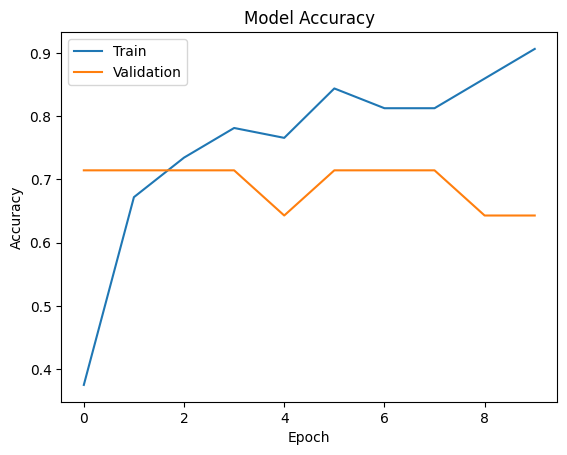

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])

plt.show()

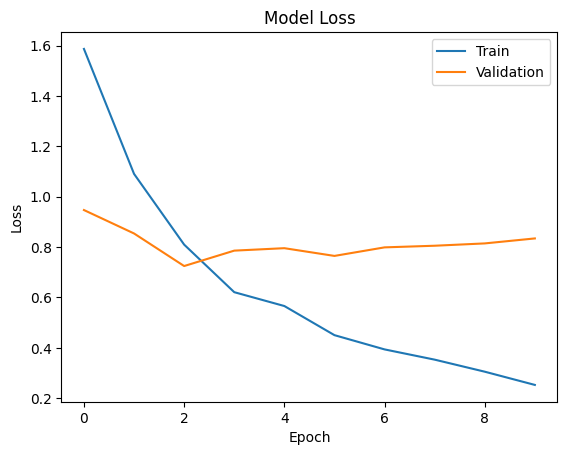

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])

plt.show()

In [23]:
model.save("ui_bug_detection_model.keras")

In [24]:
from google.colab import files
files.download("ui_bug_detection_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import numpy as np

val_data.reset()

predictions = model.predict(val_data)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


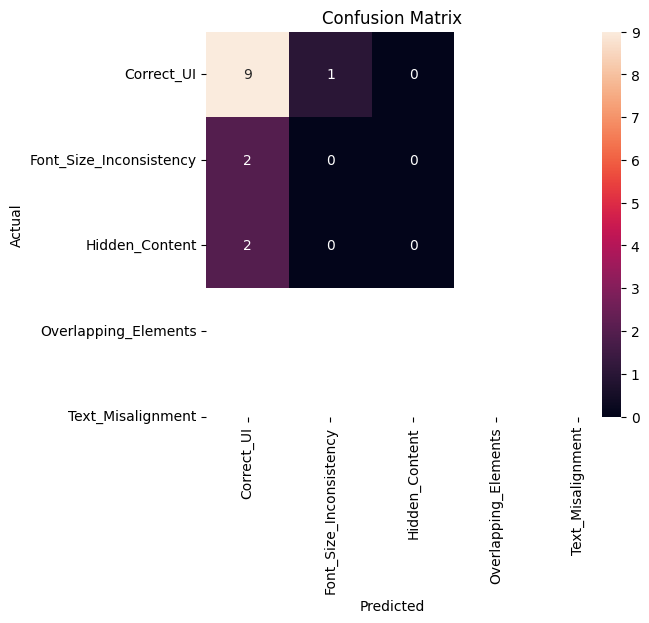

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report

labels = list(range(len(class_labels)))

print(classification_report(
    true_classes,
    predicted_classes,
    labels=labels,
    target_names=class_labels,
    zero_division=0
))

                         precision    recall  f1-score   support

             Correct_UI       0.69      0.90      0.78        10
Font_Size_Inconsistency       0.00      0.00      0.00         0
         Hidden_Content       0.00      0.00      0.00         2
   Overlapping_Elements       0.00      0.00      0.00         2
      Text_Misalignment       0.00      0.00      0.00         0

               accuracy                           0.64        14
              macro avg       0.14      0.18      0.16        14
           weighted avg       0.49      0.64      0.56        14



In [29]:
import random
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = val_data.filepaths[random.randint(0,len(val_data.filepaths)-1)]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

classes = list(train_data.class_indices.keys())
print("Predicted:", classes[np.argmax(prediction)])
print("Actual:", img_path.split("/")[-2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted: Hidden_Content
Actual: Correct_UI


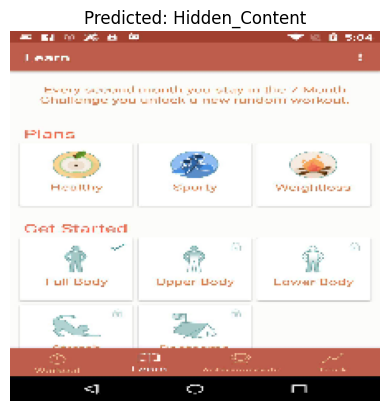

In [30]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")

plt.title("Predicted: " + classes[np.argmax(prediction)])
plt.show()

In [31]:
for i in range(5):

    img_path = val_data.filepaths[random.randint(0,len(val_data.filepaths)-1)]

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted = classes[np.argmax(prediction)]
    actual = img_path.split("/")[-2]

    print("Actual:", actual, "| Predicted:", predicted)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
Actual: Hidden_Content | Predicted: Correct_UI
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Actual: Correct_UI | Predicted: Hidden_Content
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Actual: Correct_UI | Predicted: Correct_UI
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Actual: Overlapping_Elements | Predicted: Correct_UI
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Actual: Correct_UI | Predicted: Correct_UI


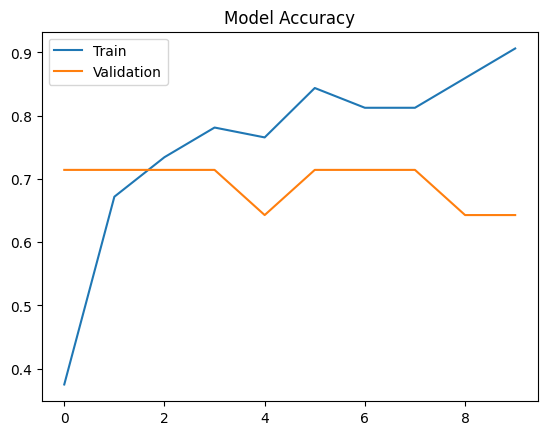

In [32]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(["Train","Validation"])
plt.title("Model Accuracy")
plt.savefig("accuracy_graph.png")

In [33]:
from google.colab import files
files.download("accuracy_graph.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
Prediction Probabilities: [[0.9742348  0.00431312 0.01339697 0.00558827 0.00246678]]
Predicted Category: Correct_UI
Confidence: 0.9742348


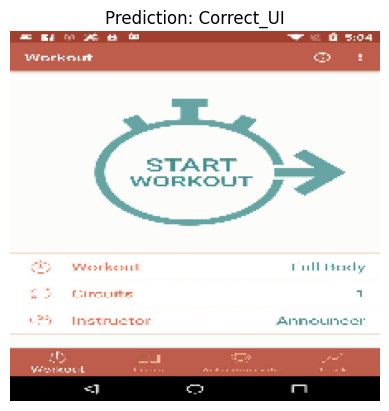

In [38]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# path of image (change filename if needed)
img_path = "/content/CNN Dataset/Correct_UI/6.jpg"

# load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

# class labels
classes = list(train_data.class_indices.keys())

predicted_index = np.argmax(prediction)
confidence = prediction[0][predicted_index]

threshold = 0.60   # confidence threshold

if confidence < threshold:
    result = "Unknown UI Defect (Not part of trained categories)"
else:
    result = classes[predicted_index]

print("Prediction Probabilities:", prediction)
print("Predicted Category:", result)
print("Confidence:", confidence)

# show image
plt.imshow(img)
plt.axis("off")
plt.title("Prediction: " + result)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Prediction Probabilities: [[0.26519915 0.00157473 0.10641143 0.01706957 0.60974514]]
Predicted Category: Text_Misalignment
Confidence: 0.60974514


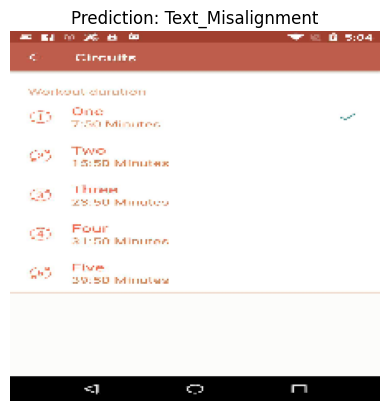

In [39]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# path of image (change filename if needed)
img_path = "/content/CNN Dataset/Text_Misalignment/7.jpg"

# load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

# class labels
classes = list(train_data.class_indices.keys())

predicted_index = np.argmax(prediction)
confidence = prediction[0][predicted_index]

threshold = 0.60   # confidence threshold

if confidence < threshold:
    result = "Unknown UI Defect (Not part of trained categories)"
else:
    result = classes[predicted_index]

print("Prediction Probabilities:", prediction)
print("Predicted Category:", result)
print("Confidence:", confidence)

# show image
plt.imshow(img)
plt.axis("off")
plt.title("Prediction: " + result)
plt.show()

In [41]:
import random

img_path = random.choice(val_data.filepaths)

print("Testing image:", img_path)

Testing image: CNN Dataset/Overlapping_Elements/1.jpg


In [42]:
from google.colab import files

uploaded = files.upload()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Prediction Probabilities: [[7.0711966e-03 9.8145765e-01 6.8668155e-03 4.4374154e-03 1.6698547e-04]]
Predicted Category: Font_Size_Inconsistency
Confidence: 0.98145765


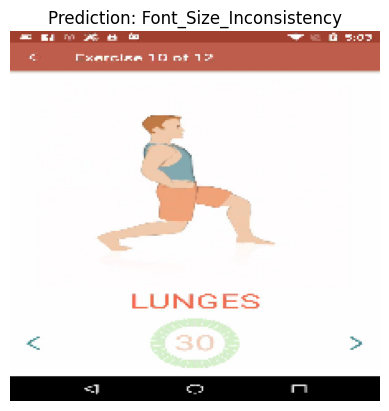

In [43]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# uploaded image path
img_path = "/content/drive/MyDrive/test_ui_images/3.jpg"

# load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

classes = list(train_data.class_indices.keys())

predicted_index = np.argmax(prediction)
confidence = prediction[0][predicted_index]

threshold = 0.60

if confidence < threshold:
    result = "Unknown UI Defect"
else:
    result = classes[predicted_index]

print("Prediction Probabilities:", prediction)
print("Predicted Category:", result)
print("Confidence:", confidence)

# show image
plt.imshow(img)
plt.axis("off")
plt.title("Prediction: " + result)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Prediction Probabilities: [[0.66164833 0.01320033 0.2535454  0.0276593  0.04394669]]
Predicted Category: Correct_UI
Confidence: 0.66164833


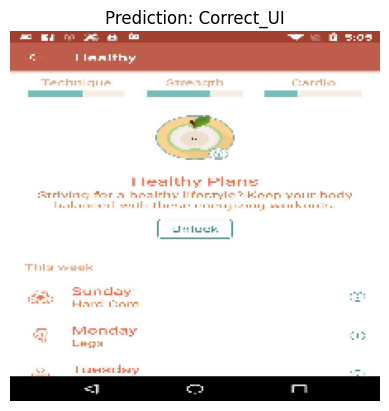

In [45]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# uploaded image path
img_path = "/content/drive/MyDrive/test_ui_images/13.jpg"

# load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

classes = list(train_data.class_indices.keys())

predicted_index = np.argmax(prediction)
confidence = prediction[0][predicted_index]

threshold = 0.60

if confidence < threshold:
    result = "Unknown UI Defect"
else:
    result = classes[predicted_index]

print("Prediction Probabilities:", prediction)
print("Predicted Category:", result)
print("Confidence:", confidence)

# show image
plt.imshow(img)
plt.axis("off")
plt.title("Prediction: " + result)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Prediction Probabilities: [[0.60131687 0.00891021 0.2744588  0.10816697 0.00714708]]
Predicted Category: Correct_UI
Confidence: 0.60131687


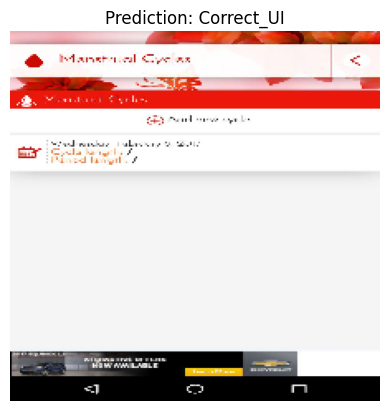

In [46]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# uploaded image path
img_path = "/content/drive/MyDrive/test_ui_images/1.jpg"

# load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

classes = list(train_data.class_indices.keys())

predicted_index = np.argmax(prediction)
confidence = prediction[0][predicted_index]

threshold = 0.60

if confidence < threshold:
    result = "Unknown UI Defect"
else:
    result = classes[predicted_index]

print("Prediction Probabilities:", prediction)
print("Predicted Category:", result)
print("Confidence:", confidence)

# show image
plt.imshow(img)
plt.axis("off")
plt.title("Prediction: " + result)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Prediction Probabilities: [[0.7848358  0.00297902 0.17087282 0.02809469 0.01321762]]
Predicted Category: Correct_UI
Confidence: 0.7848358


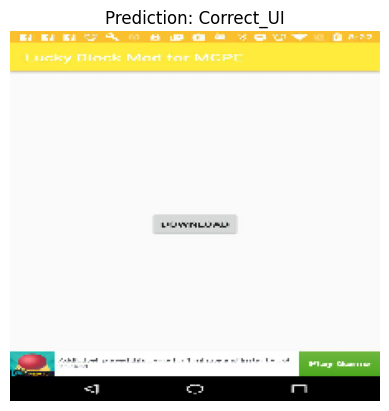

In [47]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# uploaded image path
img_path = "/content/drive/MyDrive/test_ui_images/45.jpg"

# load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

classes = list(train_data.class_indices.keys())

predicted_index = np.argmax(prediction)
confidence = prediction[0][predicted_index]

threshold = 0.60

if confidence < threshold:
    result = "Unknown UI Defect"
else:
    result = classes[predicted_index]

print("Prediction Probabilities:", prediction)
print("Predicted Category:", result)
print("Confidence:", confidence)

# show image
plt.imshow(img)
plt.axis("off")
plt.title("Prediction: " + result)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Prediction Probabilities: [[0.42746225 0.00531566 0.1312403  0.00864675 0.42733502]]
Predicted Category: Unknown UI Defect
Confidence: 0.42746225


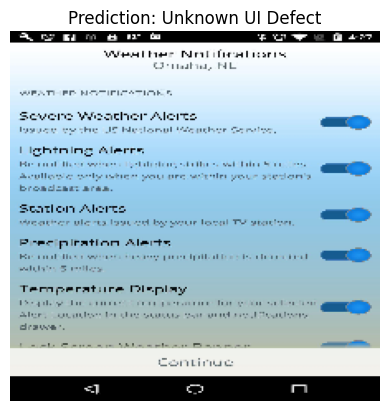

In [48]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# uploaded image path
img_path = "/content/drive/MyDrive/test_ui_images/58.jpg"

# load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

classes = list(train_data.class_indices.keys())

predicted_index = np.argmax(prediction)
confidence = prediction[0][predicted_index]

threshold = 0.60

if confidence < threshold:
    result = "Unknown UI Defect"
else:
    result = classes[predicted_index]

print("Prediction Probabilities:", prediction)
print("Predicted Category:", result)
print("Confidence:", confidence)

# show image
plt.imshow(img)
plt.axis("off")
plt.title("Prediction: " + result)
plt.show()

In [51]:
import os
import random

test_folder = "/content/drive/MyDrive/test_ui_images"

img_path = os.path.join(test_folder, random.choice(os.listdir(test_folder)))

print("Testing Image:", img_path)

Testing Image: /content/drive/MyDrive/test_ui_images/45.jpg
